In [13]:
import os 
import sys
import json

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

def is_project_root(path):
    path = Path(path)

    return (
        (path / "eytnet").is_dir()
        and (path / "configs").is_dir()
        and (path / "pyproject.toml").is_file()
    )

current = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        path for path in [current, *current.parents] if is_project_root(path)

    ),
    None,
)

if PROJECT_ROOT is None:
    content = Path("/content")
    if content.is_dir():
        PROJECT_ROOT = next(
            (
                path for path in content.iterdir() if ( path.is_dir() and is_project_root(path)
            )
        ),
        None,
    )

assert PROJECT_ROOT is not None, (
    "Proje bulunamadı. Önce Notebook 11'i "
    "aynı ortamda çalıştır."
)

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from eytnet.metrics import (
    iou_matrix,
    load_ground_truth,
)

print("Proje:", PROJECT_ROOT)

Proje: C:\Users\omert\Desktop\fire_guncel_repo


In [14]:
%pip install -q -U kagglehub

Note: you may need to restart the kernel to use updated packages.


c:\Users\omert\Desktop\fire_guncel_repo\.venv\Scripts\python.exe: No module named pip


In [15]:
import kagglehub
try:
    from kagglehub import drive
    drive.mount(
        "/content/drive",
        force_remount=False,
    )
except ImportError:
    print("Yerel ortam: drive bulunamadı")

def valid_dataset(path):
    path = Path(path)
    return all(
        (path / split / "images").is_dir()
        and (path / split / "labels").is_dir()
        for split in ["train", "val", "test"]
    )

local_data = PROJECT_ROOT / "data"

if valid_dataset(local_data):
    DATA_ROOT = local_data

else:
    downloaded_path =Path(
        kagglehub.dataset_download("pengbo00/home-fire-dataset")

    )

    candidates = [downloaded_path]

    for images_dir in downloaded_path.rglob(
        "images"
    ):
        if images_dir.parent.name == "train":
            candidates.append(
                images_dir.parent.parent
            )

    DATA_ROOT = next(
        path
        for path in candidates
        if valid_dataset(path)
    )

test_gt = load_ground_truth(DATA_ROOT,"test",)

TEST_IMAGE_DIR = (
    DATA_ROOT / "test" / "images"
)

print("Dataset:", DATA_ROOT)
print("Test görüntüsü:", len(test_gt))

Yerel ortam: drive bulunamadı
Dataset: C:\Users\omert\Desktop\fire_guncel_repo\data
Test görüntüsü: 1300


In [16]:
import time
import torch

from torch.utils.data import DataLoader

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
)
from torchvision.models.detection.faster_rcnn import (
    FastRCNNPredictor,
)

from eytnet.config import Config
from eytnet.model import build_model
from eytnet.dataset import build_dataloader

from eytnet.postprocess import (
    collect_predictions as collect_eyt_predictions,
    postprocess as eyt_postprocess,
    anchors_to_tensors,
)

from eytnet.metrics_compat import (
    collect_predictions as collect_frcnn_predictions,
)

from eytnet.metrics import (
    confidence_sweep,
    evaluate_detections,
    results_table,
)

try:
    from helpers.datahelper import (
        FireDataset,
        collate_fn as frcnn_collate_fn,
    )
except ImportError:
    from helpers.datahelperrr import (
        FireDataset,
        collate_fn as frcnn_collate_fn,
    )


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


def build_fasterrcnn():
    model = fasterrcnn_resnet50_fpn_v2(
        weights=None,
        weights_backbone=None,
        box_batch_size_per_image=512,
        box_positive_fraction=0.25,
    )

    in_features = (
        model.roi_heads
        .box_predictor
        .cls_score
        .in_features
    )

    model.roi_heads.box_predictor = (
        FastRCNNPredictor(
            in_features,
            3,  # background, fire, smoke
        )
    )

    model.transform.min_size = (640,)
    model.transform.max_size = 640

    return model

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [17]:
EYT_RUN_DIR = (
    PROJECT_ROOT
    / "models"
    / "eytnet"
    / "eytnet_final_v1_opt_obj01"
)

EYT_CHECKPOINT = (
    EYT_RUN_DIR
    / "weights"
    / "best.pt"
)

EYT_SELECTION_FILE = (
    EYT_RUN_DIR
    / "test_results.json"
)


FRCNN_RUN_NAME = (
    "fasterrcnn_v2_unfreeze_l3_step16_22_es_full"
)

frcnn_candidates = list(
    (PROJECT_ROOT / "models").glob(
        f"**/{FRCNN_RUN_NAME}/weights/best.pt"
    )
)


assert EYT_CHECKPOINT.is_file(), (
    "EYT-Net checkpoint bulunamadı:\n"
    f"{EYT_CHECKPOINT}"
)

assert EYT_SELECTION_FILE.is_file(), (
    "EYT-Net test_results.json bulunamadı. "
    "Önce Notebook 11'in son hücresini çalıştır."
)

assert frcnn_candidates, (
    "Faster R-CNN final best.pt bulunamadı."
)


FRCNN_CHECKPOINT = frcnn_candidates[0]
FRCNN_RUN_DIR = (
    FRCNN_CHECKPOINT.parent.parent
)


def checkpoint_state(path):
    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    if "model" in checkpoint:
        return checkpoint["model"]

    if "state_dict" in checkpoint:
        return checkpoint["state_dict"]

    return checkpoint


# EYT-Net modelini yükle
raw = json.loads(
    (EYT_RUN_DIR / "config.json")
    .read_text(encoding="utf-8")
)

raw["data_root"] = str(DATA_ROOT)

cfg = Config(raw)
cfg.data_root = DATA_ROOT
cfg.run_dir = EYT_RUN_DIR
cfg.batch_size = 8
cfg.num_workers = 0


eyt_selection = json.loads(
    EYT_SELECTION_FILE.read_text(
        encoding="utf-8"
    )
)

EYT_SCORE = float(
    eyt_selection["score_threshold"]
)

EYT_NMS = float(
    eyt_selection["nms_iou_threshold"]
)

cfg.nms_iou_threshold = EYT_NMS


eyt_model = build_model(cfg)

eyt_model.load_state_dict(
    checkpoint_state(EYT_CHECKPOINT)
)

eyt_model = (
    eyt_model
    .to(device)
    .eval()
)


# Faster R-CNN modelini yükle
FRCNN_NMS = 0.50

frcnn_model = build_fasterrcnn()

frcnn_model.load_state_dict(
    checkpoint_state(FRCNN_CHECKPOINT)
)

frcnn_model.roi_heads.nms_thresh = (
    FRCNN_NMS
)

frcnn_model = (
    frcnn_model
    .to(device)
    .eval()
)


if device.type == "cuda":
    torch.cuda.empty_cache()


OUTPUT_DIR = (
    PROJECT_ROOT
    / "models"
    / "comparison"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("EYT-Net checkpoint:")
print(EYT_CHECKPOINT)

print("\nFaster R-CNN checkpoint:")
print(FRCNN_CHECKPOINT)

print("\nEYT confidence:", EYT_SCORE)
print("EYT NMS:", EYT_NMS)
print("Faster R-CNN NMS:", FRCNN_NMS)
print("Çıktı klasörü:", OUTPUT_DIR)

EYT-Net checkpoint:
C:\Users\omert\Desktop\fire_guncel_repo\models\eytnet\eytnet_final_v1_opt_obj01\weights\best.pt

Faster R-CNN checkpoint:
C:\Users\omert\Desktop\fire_guncel_repo\models\fasterrcnn_v2_unfreeze_l3_step16_22_es_full-20260819T000737Z-1-001\fasterrcnn_v2_unfreeze_l3_step16_22_es_full\weights\best.pt

EYT confidence: 0.35
EYT NMS: 0.3
Faster R-CNN NMS: 0.5
Çıktı klasörü: C:\Users\omert\Desktop\fire_guncel_repo\models\comparison


In [18]:
eyt_test_loader = build_dataloader(
    cfg,
    "test",
)

frcnn_val_dataset = FireDataset(
    DATA_ROOT / "val",
    augment=False,
)

frcnn_test_dataset = FireDataset(
    DATA_ROOT / "test",
    augment=False,
)

frcnn_val_loader = DataLoader(
    frcnn_val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=frcnn_collate_fn,
)

frcnn_test_loader = DataLoader(
    frcnn_test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=frcnn_collate_fn,
)

val_gt = load_ground_truth(
    DATA_ROOT,
    "val",
)

test_gt = load_ground_truth(
    DATA_ROOT,
    "test",
)

print("Faster R-CNN validation inference başlıyor...")

frcnn_val_predictions, _ = (
    collect_frcnn_predictions(
        frcnn_model,
        frcnn_val_loader,
        device,
        score_threshold=0.01,
        image_size=640,
    )
)

CONFIDENCE_VALUES = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.50,
    0.60,
]

frcnn_sweep = pd.DataFrame(
    confidence_sweep(
        frcnn_val_predictions,
        val_gt,
        ["fire", "smoke"],
        thresholds=CONFIDENCE_VALUES,
    )
)

best_frcnn_row = (
    frcnn_sweep
    .sort_values(
        ["f2", "f1", "threshold"],
        ascending=[False, False, False],
    )
    .iloc[0]
)

FRCNN_SCORE = float(
    best_frcnn_row["threshold"]
)

display(
    frcnn_sweep
    .sort_values(
        ["f2", "f1"],
        ascending=False,
    )
    .round(4)
)

print(
    "Seçilen Faster R-CNN confidence:",
    FRCNN_SCORE,
)

frcnn_sweep.to_csv(
    OUTPUT_DIR
    / "fasterrcnn_threshold_selection.csv",
    index=False,
)

Faster R-CNN validation inference başlıyor...


,threshold,precision,recall,f1,f2,tp,fp,fn
8,0.50,0.9100,0.9538,0.9314,0.9447,1507,149,73
7,0.40,0.8947,0.9570,0.9248,0.9438,1512,178,68
6,0.35,0.8890,0.9576,0.9220,0.9430,1513,189,67
9,0.60,0.9162,0.9481,0.9319,0.9415,1498,137,82
4,0.25,0.8708,0.9601,0.9133,0.9408,1517,225,63
5,0.30,0.8781,0.9576,0.9161,0.9406,1513,210,67
3,0.20,0.8558,0.9614,0.9055,0.9382,1519,256,61
2,0.15,0.8371,0.9627,0.8955,0.9346,1521,296,59
1,0.10,0.8053,0.9658,0.8783,0.9288,1526,369,54
0,0.05,0.7556,0.9684,0.8488,0.9167,1530,495,50


Seçilen Faster R-CNN confidence: 0.5


In [19]:
eyt_test_loader = build_dataloader(
    cfg,
    "test",
)

frcnn_val_dataset = FireDataset(
    DATA_ROOT / "val",
    augment=False,
)

frcnn_test_dataset = FireDataset(
    DATA_ROOT / "test",
    augment=False,
)

frcnn_val_loader = DataLoader(
    frcnn_val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=frcnn_collate_fn,
)

frcnn_test_loader = DataLoader(
    frcnn_test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=frcnn_collate_fn,
)

val_gt = load_ground_truth(
    DATA_ROOT,
    "val",
)

test_gt = load_ground_truth(
    DATA_ROOT,
    "test",
)

print("Faster R-CNN validation inference başlıyor...")

frcnn_val_predictions, _ = (
    collect_frcnn_predictions(
        frcnn_model,
        frcnn_val_loader,
        device,
        score_threshold=0.01,
        image_size=640,
    )
)

CONFIDENCE_VALUES = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.50,
    0.60,
]

frcnn_sweep = pd.DataFrame(
    confidence_sweep(
        frcnn_val_predictions,
        val_gt,
        ["fire", "smoke"],
        thresholds=CONFIDENCE_VALUES,
    )
)

best_frcnn_row = (
    frcnn_sweep
    .sort_values(
        ["f2", "f1", "threshold"],
        ascending=[False, False, False],
    )
    .iloc[0]
)

FRCNN_SCORE = float(
    best_frcnn_row["threshold"]
)

display(
    frcnn_sweep
    .sort_values(
        ["f2", "f1"],
        ascending=False,
    )
    .round(4)
)

print(
    "Seçilen Faster R-CNN confidence:",
    FRCNN_SCORE,
)

frcnn_sweep.to_csv(
    OUTPUT_DIR
    / "fasterrcnn_threshold_selection.csv",
    index=False,
)

Faster R-CNN validation inference başlıyor...


,threshold,precision,recall,f1,f2,tp,fp,fn
8,0.50,0.9100,0.9538,0.9314,0.9447,1507,149,73
7,0.40,0.8947,0.9570,0.9248,0.9438,1512,178,68
6,0.35,0.8890,0.9576,0.9220,0.9430,1513,189,67
9,0.60,0.9162,0.9481,0.9319,0.9415,1498,137,82
4,0.25,0.8708,0.9601,0.9133,0.9408,1517,225,63
5,0.30,0.8781,0.9576,0.9161,0.9406,1513,210,67
3,0.20,0.8558,0.9614,0.9055,0.9382,1519,256,61
2,0.15,0.8371,0.9627,0.8955,0.9346,1521,296,59
1,0.10,0.8053,0.9658,0.8783,0.9288,1526,369,54
0,0.05,0.7556,0.9684,0.8488,0.9167,1530,495,50


Seçilen Faster R-CNN confidence: 0.5


EYT-Net test inference başlıyor...
Faster R-CNN test inference başlıyor...
EYT-Net


,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.5569,0.2724,0.4280,0.6656,0.5209,0.5990,597,798,300
smoke,0.1783,0.0623,0.3662,0.2046,0.2626,0.2245,141,244,548
TOPLAM,0.3676,0.1673,0.4146,0.4653,0.4385,0.4542,738,1042,848


Faster R-CNN


,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.9458,0.6211,0.9037,0.9309,0.9171,0.9253,835,89,62
smoke,0.9155,0.5568,0.8426,0.9013,0.8710,0.8889,621,116,68
TOPLAM,0.9307,0.5890,0.8766,0.9180,0.8968,0.9094,1456,205,130


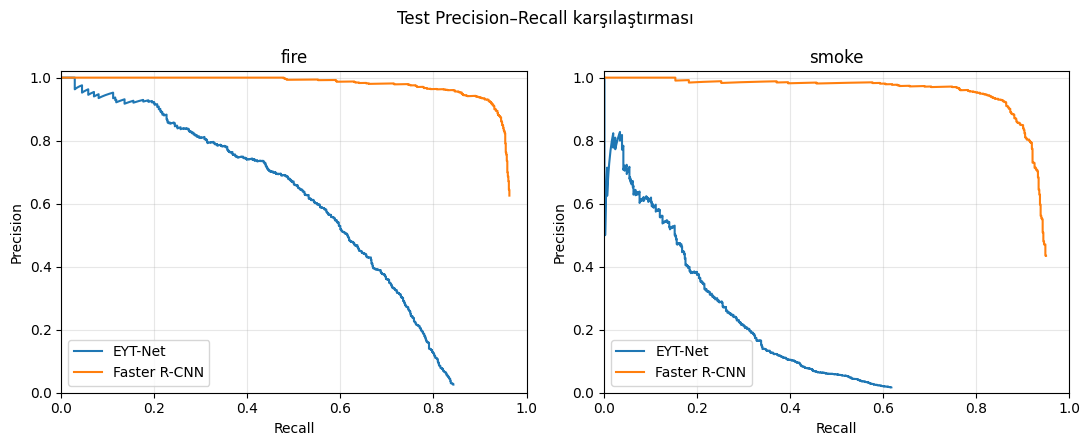

In [20]:
print("EYT-Net test inference başlıyor...")

eyt_predictions = collect_eyt_predictions(
    eyt_model,
    eyt_test_loader,
    cfg,
    device,
    score_threshold=cfg.decode_score_floor,
)

print("Faster R-CNN test inference başlıyor...")

frcnn_predictions, _ = (
    collect_frcnn_predictions(
        frcnn_model,
        frcnn_test_loader,
        device,
        score_threshold=0.01,
        image_size=640,
    )
)

eyt_evaluation = evaluate_detections(
    eyt_predictions,
    test_gt,
    cfg.class_names,
    score_threshold=EYT_SCORE,
    iou_threshold=0.50,
    map5095=True,
)

frcnn_evaluation = evaluate_detections(
    frcnn_predictions,
    test_gt,
    ["fire", "smoke"],
    score_threshold=FRCNN_SCORE,
    iou_threshold=0.50,
    map5095=True,
)

print("EYT-Net")
display(results_table(eyt_evaluation))

print("Faster R-CNN")
display(results_table(frcnn_evaluation))


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)

for axis, class_name in zip(
    axes,
    ["fire", "smoke"],
):
    for method, evaluation in [
        ("EYT-Net", eyt_evaluation),
        ("Faster R-CNN", frcnn_evaluation),
    ]:
        recall, precision = (
            evaluation["curves"][class_name]
        )

        axis.plot(
            recall,
            precision,
            label=method,
        )

    axis.set_title(class_name)
    axis.set_xlabel("Recall")
    axis.set_ylabel("Precision")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)
    axis.grid(alpha=0.3)
    axis.legend()

plt.suptitle(
    "Test Precision–Recall karşılaştırması"
)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "pr_curve_comparison.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [21]:
def synchronize():
    if device.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def time_eytnet(
    model,
    loader,
    config,
    score_threshold,
    limit=100,
):
    model.eval()

    anchors = anchors_to_tensors(
        config,
        device,
    )

    warmup_images, _, _ = next(
        iter(loader)
    )

    warmup_images = warmup_images.to(
        device
    )

    for _ in range(3):
        outputs = model(warmup_images)

        eyt_postprocess(
            outputs,
            config,
            score_threshold,
            anchors,
        )

    synchronize()

    total_seconds = 0.0
    total_images = 0

    for images, _, _ in loader:
        if total_images >= limit:
            break

        images = images.to(
            device,
            non_blocking=True,
        )

        synchronize()
        started = time.perf_counter()

        outputs = model(images)

        eyt_postprocess(
            outputs,
            config,
            score_threshold,
            anchors,
        )

        synchronize()

        total_seconds += (
            time.perf_counter() - started
        )

        total_images += len(images)

    milliseconds = (
        total_seconds / total_images * 1000
    )

    return milliseconds, 1000 / milliseconds


@torch.no_grad()
def time_fasterrcnn(
    model,
    loader,
    score_threshold,
    limit=100,
):
    model.eval()

    old_threshold = (
        model.roi_heads.score_thresh
    )

    model.roi_heads.score_thresh = (
        score_threshold
    )

    warmup_images, _ = next(iter(loader))

    warmup_images = [
        image.to(device)
        for image in warmup_images
    ]

    for _ in range(3):
        model(warmup_images)

    synchronize()

    total_seconds = 0.0
    total_images = 0

    for images, _ in loader:
        if total_images >= limit:
            break

        images = [
            image.to(
                device,
                non_blocking=True,
            )
            for image in images
        ]

        synchronize()
        started = time.perf_counter()

        model(images)

        synchronize()

        total_seconds += (
            time.perf_counter() - started
        )

        total_images += len(images)

    model.roi_heads.score_thresh = (
        old_threshold
    )

    milliseconds = (
        total_seconds / total_images * 1000
    )

    return milliseconds, 1000 / milliseconds


cfg.batch_size = 1

eyt_timing_loader = build_dataloader(
    cfg,
    "test",
)

frcnn_timing_loader = DataLoader(
    frcnn_test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=frcnn_collate_fn,
)

eyt_ms, eyt_fps = time_eytnet(
    eyt_model,
    eyt_timing_loader,
    cfg,
    EYT_SCORE,
)

frcnn_ms, frcnn_fps = time_fasterrcnn(
    frcnn_model,
    frcnn_timing_loader,
    FRCNN_SCORE,
)

print(
    f"EYT-Net: {eyt_ms:.2f} ms/görüntü, "
    f"{eyt_fps:.2f} FPS"
)

print(
    f"Faster R-CNN: {frcnn_ms:.2f} ms/görüntü, "
    f"{frcnn_fps:.2f} FPS"
)


def json_ready(value):
    if isinstance(value, dict):
        return {
            key: json_ready(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            json_ready(item)
            for item in value
        ]

    if isinstance(value, np.generic):
        return value.item()

    return value


eyt_results = {
    "model": "EYT-Net",
    "checkpoint": str(EYT_CHECKPOINT),
    "score_threshold": EYT_SCORE,
    "nms_iou_threshold": EYT_NMS,
    "inference_ms_per_image": eyt_ms,
    "fps": eyt_fps,
    "per_class": eyt_evaluation["per_class"],
    "overall": eyt_evaluation["overall"],
}

frcnn_results = {
    "model": "Faster R-CNN",
    "checkpoint": str(FRCNN_CHECKPOINT),
    "score_threshold": FRCNN_SCORE,
    "nms_iou_threshold": FRCNN_NMS,
    "inference_ms_per_image": frcnn_ms,
    "fps": frcnn_fps,
    "per_class": frcnn_evaluation["per_class"],
    "overall": frcnn_evaluation["overall"],
}

np.savez_compressed(
    OUTPUT_DIR
    / "eytnet_test_predictions.npz",
    **eyt_predictions,
)

np.savez_compressed(
    OUTPUT_DIR
    / "fasterrcnn_test_predictions.npz",
    **frcnn_predictions,
)

(
    OUTPUT_DIR / "eytnet_test_results.json"
).write_text(
    json.dumps(
        json_ready(eyt_results),
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

(
    OUTPUT_DIR
    / "fasterrcnn_test_results.json"
).write_text(
    json.dumps(
        json_ready(frcnn_results),
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("Sonuçlar kaydedildi:", OUTPUT_DIR)

EYT-Net: 23.27 ms/görüntü, 42.98 FPS
Faster R-CNN: 65.83 ms/görüntü, 15.19 FPS
Sonuçlar kaydedildi: C:\Users\omert\Desktop\fire_guncel_repo\models\comparison
